In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ASL-Sensor-Dataglove-Dataset.zip to ASL-Sensor-Dataglove-Dataset.zip


In [ ]:
import zipfile
import os

zip_path = "ASL-Sensor-Dataglove-Dataset.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

# Check contents
print(os.listdir(extract_path))

Unzipped successfully
['ASL-Sensor-Dataglove-Dataset']


In [ ]:
data_dir = os.path.join("dataset", "ASL-Sensor-Dataglove-Dataset")

folders = sorted(os.listdir(data_dir))
print("Folders:", folders)
print("Total folders:", len(folders))

Folders: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025']
Total folders: 25


In [ ]:
import os

for folder in folders:
    folder_path = os.path.join(data_dir, folder)

    files = os.listdir(folder_path)
    csv_files = [f for f in files if f.endswith(".csv")]

    print(f"{folder} -> total files: {len(csv_files)}")

001 -> total files: 40
002 -> total files: 40
003 -> total files: 40
004 -> total files: 40
005 -> total files: 40
006 -> total files: 40
007 -> total files: 40
008 -> total files: 40
009 -> total files: 40
010 -> total files: 40
011 -> total files: 40
012 -> total files: 40
013 -> total files: 40
014 -> total files: 40
015 -> total files: 40
016 -> total files: 40
017 -> total files: 40
018 -> total files: 40
019 -> total files: 40
020 -> total files: 40
021 -> total files: 40
022 -> total files: 40
023 -> total files: 40
024 -> total files: 40
025 -> total files: 40


In [ ]:
allowed_labels = list("abcdefghijklmnopqrstuvwxyz") + ["yes", "you", "no", "me"]

print("Total allowed labels:", len(allowed_labels))
print(allowed_labels)

Total allowed labels: 30
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'yes', 'you', 'no', 'me']


In [ ]:
selected_features = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5",
    "GYRx", "GYRy", "GYRz",
    "ACCx", "ACCy", "ACCz"
]

print("Total features:", len(selected_features))

Total features: 11


In [ ]:
import numpy as np
import pandas as pd
import os

X = []
y = []

for folder in folders:
    folder_path = os.path.join(data_dir, folder)

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):

            label = file.replace(".csv", "")

            # ✅ keep only desired labels
            if label not in allowed_labels:
                continue

            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # ✅ select only 11 features
            df = df[selected_features]

            X.append(df.values)   # KEEP sequence
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (750, 1500, 11)
y shape: (750,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded sample:", y_encoded[:10])

Classes: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'me' 'n' 'no' 'o' 'p'
 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'yes' 'you' 'z']
Encoded sample: [ 4 29 10 24 15  8 12  9 13  1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (600, 1500, 11)
Test shape: (150, 1500, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

# get shape
num_samples, time_steps, num_features = X_train.shape

# reshape to 2D
X_train_reshaped = X_train.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# reshape back to 3D
X_train = X_train_scaled.reshape(num_samples, time_steps, num_features)
X_test = X_test_scaled.reshape(X_test.shape[0], time_steps, num_features)

print("After normalization:", X_train.shape)

After normalization: (600, 1500, 11)


In [ ]:
print("Mean:", X_train.mean())
print("Std:", X_train.std())

Mean: -2.1021408272902433e-14
Std: 1.0000000000001703


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(1500, 11)),
    layers.LSTM(32),
    layers.Dense(64, activation='relu'),
    layers.Dense(30, activation='softmax')  # 30 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1500, 64)       │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,934 (140.37 KB)

 Trainable params: 35,934 (140.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(1500, 11)),   # ✅ proper way
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(64, activation='relu'),
    layers.Dense(30, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1437 - loss: 3.2858 - val_accuracy: 0.2833 - val_loss: 3.1229
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3208 - loss: 2.8815 - val_accuracy: 0.3583 - val_loss: 2.6429
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4167 - loss: 2.3200 - val_accuracy: 0.3917 - val_loss: 2.1476
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5000 - loss: 1.8075 - val_accuracy: 0.4417 - val_loss: 1.7736
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5625 - loss: 1.4864 - val_accuracy: 0.5333 - val_loss: 1.5792
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6125 - loss: 1.2851 - val_accuracy: 0.4167 - val_loss: 1.6080
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5521 - loss: 1.4321 - val_accuracy: 0.4417 - val_loss: 1.5212
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5813 - loss: 1.2461 - val_accuracy: 0.4500 - val_loss:

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6104 - loss: 1.1229 - val_accuracy: 0.5917 - val_loss: 1.1403
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7021 - loss: 0.9091 - val_accuracy: 0.6083 - val_loss: 1.2063
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7292 - loss: 0.8622 - val_accuracy: 0.6667 - val_loss: 0.9472
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7625 - loss: 0.7116 - val_accuracy: 0.6833 - val_loss: 0.8920
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7771 - loss: 0.6527 - val_accuracy: 0.7000 - val_loss: 0.8699
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7958 - loss: 0.5748 - val_accuracy: 0.7083 - val_loss: 0.8555
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7958 - loss: 0.5755 - val_accuracy: 0.6417 - val_loss: 0.8831
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7812 - loss: 0.6132 - val_accuracy: 0.7250 - val_loss:

In [ ]:
def downsample(sequence, target_length=200):
    idx = np.linspace(0, len(sequence) - 1, target_length).astype(int)
    return sequence[idx]

In [ ]:
X_down = np.array([downsample(seq) for seq in X])

print("New shape:", X_down.shape)

New shape: (750, 200, 11)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_down, y_encoded, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (600, 200, 11)
Test: (150, 200, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

num_samples, time_steps, num_features = X_train.shape

X_train_reshaped = X_train.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

X_train = X_train_scaled.reshape(num_samples, time_steps, num_features)
X_test = X_test_scaled.reshape(X_test.shape[0], time_steps, num_features)

print("Normalized shape:", X_train.shape)

Normalized shape: (600, 200, 11)


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200, 11)),

    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(30, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 200, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,934 (140.37 KB)

 Trainable params: 35,934 (140.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.1125 - loss: 3.3205 - val_accuracy: 0.2250 - val_loss: 3.1761
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.2396 - loss: 2.9782 - val_accuracy: 0.3417 - val_loss: 2.7147
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.3104 - loss: 2.4995 - val_accuracy: 0.3167 - val_loss: 2.2013
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.3854 - loss: 2.0354 - val_accuracy: 0.4000 - val_loss: 1.8378
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.4521 - loss: 1.7385 - val_accuracy: 0.4583 - val_loss: 1.5991
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.5437 - loss: 1.4732 - val_accuracy: 0.5333 - val_loss: 1.3672
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.5708 - loss: 1.3173 - val_accuracy: 0.5333 - val_loss: 1.3323
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.5938 - loss: 1.2773 - val_accuracy: 0

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6467 - loss: 0.9274
Test Accuracy: 0.6466666460037231


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200, 11)),

    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(30, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 358ms/step - accuracy: 0.1562 - loss: 3.1793 - val_accuracy: 0.1917 - val_loss: 2.8490
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.3125 - loss: 2.5528 - val_accuracy: 0.4333 - val_loss: 2.1662


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 354ms/step - accuracy: 0.2979 - loss: 2.5197 - val_accuracy: 0.4000 - val_loss: 2.1598
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.4229 - loss: 1.9656 - val_accuracy: 0.5750 - val_loss: 1.6237
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step - accuracy: 0.5063 - loss: 1.6135 - val_accuracy: 0.4917 - val_loss: 1.3995
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - accuracy: 0.5417 - loss: 1.4018 - val_accuracy: 0.5917 - val_loss: 1.2247
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.5938 - loss: 1.2292 - val_accuracy: 0.5917 - val_loss: 1.1603
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.5792 - loss: 1.2288 - val_accuracy: 0.5833 - val_loss: 1.1806
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.5896 - loss: 1.1307 - val_accuracy: 0.6250 - val_loss: 1.1138
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.6458 - loss: 1.0451 - val_accuracy:

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.6933 - loss: 0.8448
Test Accuracy: 0.6933333277702332


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200, 11)),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32)
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(30, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,318 (360.62 KB)

 Trainable params: 92,318 (360.62 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 288ms/step - accuracy: 0.1354 - loss: 3.2607 - val_accuracy: 0.2667 - val_loss: 2.9965
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - accuracy: 0.3146 - loss: 2.7137 - val_accuracy: 0.3667 - val_loss: 2.3567
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - accuracy: 0.4229 - loss: 2.0871 - val_accuracy: 0.4583 - val_loss: 1.8321
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.5167 - loss: 1.5771 - val_accuracy: 0.5500 - val_loss: 1.4260
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.6042 - loss: 1.3248 - val_accuracy: 0.6250 - val_loss: 1.1732
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.6562 - loss: 1.1120 - val_accuracy: 0.7167 - val_loss: 0.9988
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step - accuracy: 0.6854 - loss: 1.0317 - val_accuracy: 0.7000 - val_loss: 0.9578
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 278ms/step - accuracy: 0.7250 - loss: 0.8705 - val_accurac

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.7400 - loss: 0.7115
Test Accuracy: 0.7400000095367432


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix shape:", cm.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 419ms/step
Confusion Matrix shape: (30, 30)


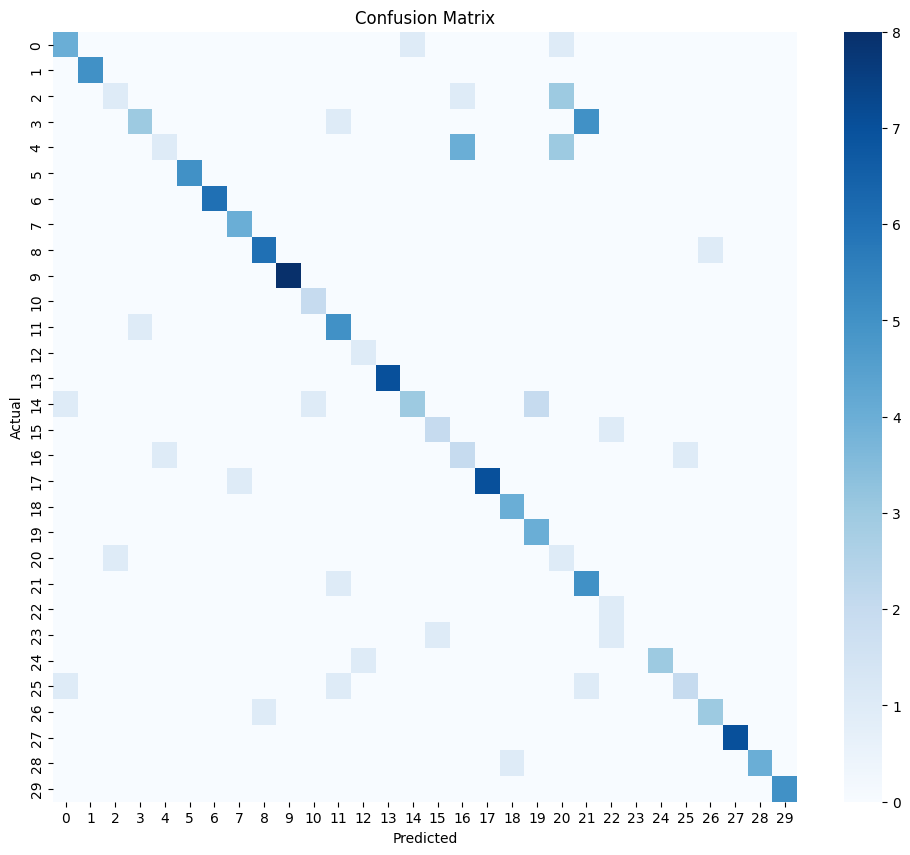

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
labels = ['a','b','c','d','e','f','g','h','i','j','k','l','m',
          'me','n','no','o','p','q','r','s','t','u','v','w',
          'x','y','yes','you','z']

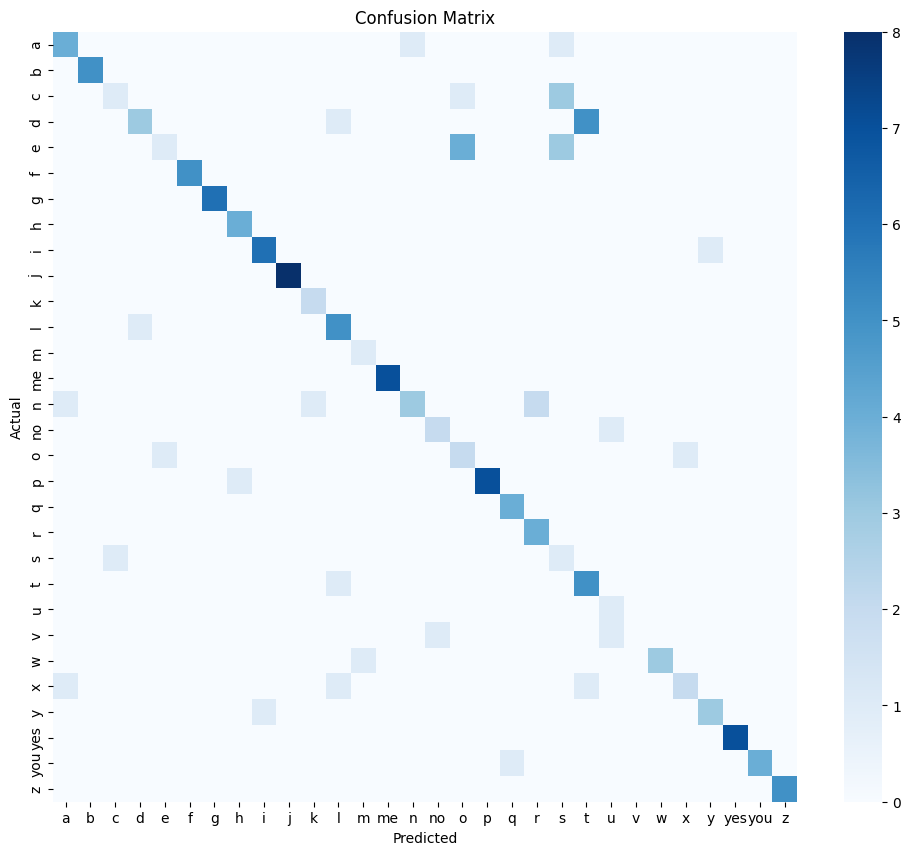

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

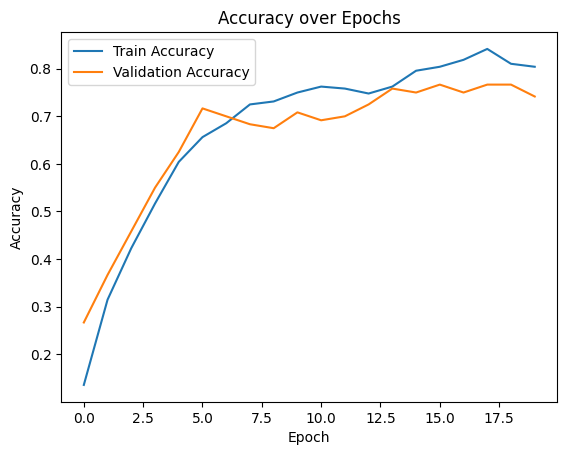

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

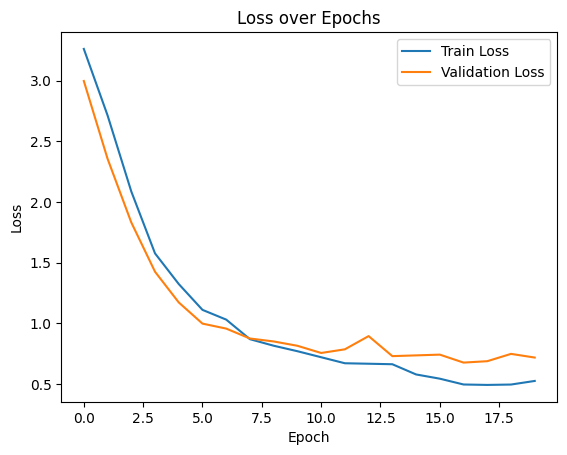

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

data_path = "ASL-Sensor-Dataglove-Dataset"

X = []       # sequences
y = []       # labels
groups = []  # person IDs

selected_labels = list("abcdefghijklmnopqrstuvwxyz") + ["yes", "no", "me"]

features = ['flex_1','flex_2','flex_3','flex_4','flex_5',
            'GYRx','GYRy','GYRz',
            'ACCx','ACCy','ACCz']

for folder in sorted(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)

    if not os.path.isdir(folder_path):
        continue

    person_id = folder  # 👈 group info

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        label = file.replace(".csv", "")

        if label not in selected_labels:
            continue

        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        # select features
        df = df[features]

        sequence = df.values  # shape (1500, 11)

        X.append(sequence)
        y.append(label)
        groups.append(person_id)

In [ ]:
X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

X: (725, 1500, 11)
y: (725,)
groups: (725,)


In [ ]:
import numpy as np

def downsample(sequence, target_length=100):
    idx = np.linspace(0, len(sequence) - 1, target_length).astype(int)
    return sequence[idx]

X_down = np.array([downsample(seq) for seq in X])

print("X_down shape:", X_down.shape)

X_down shape: (725, 100, 11)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'me' 'n' 'no' 'o' 'p'
 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'yes' 'z']


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, test_idx in gss.split(X_down, y_encoded, groups):
    X_train, X_test = X_down[train_idx], X_down[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (580, 100, 11)
Test: (145, 100, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

num_samples, time_steps, num_features = X_train.shape

X_train_reshaped = X_train.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

X_train = X_train_scaled.reshape(num_samples, time_steps, num_features)
X_test = X_test_scaled.reshape(X_test.shape[0], time_steps, num_features)

print("Normalized:", X_train.shape)

Normalized: (580, 100, 11)


In [ ]:
def augment(sequence):
    noise = np.random.normal(0, 0.01, sequence.shape)
    scale = np.random.uniform(0.9, 1.1)
    return (sequence * scale) + noise

X_aug = np.array([augment(seq) for seq in X_train])

X_train_new = np.concatenate([X_train, X_aug])
y_train_new = np.concatenate([y_train, y_train])

from sklearn.utils import shuffle
X_train_new, y_train_new = shuffle(X_train_new, y_train_new, random_state=42)

print("Augmented:", X_train_new.shape)

Augmented: (1160, 100, 11)


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100, 11)),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32)
    ),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(30, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_new, y_train_new,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.1875 - loss: 3.0403 - val_accuracy: 0.4009 - val_loss: 2.4221
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.4774 - loss: 1.9609 - val_accuracy: 0.6595 - val_loss: 1.3616
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.6315 - loss: 1.2158 - val_accuracy: 0.7241 - val_loss: 0.9099
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.7026 - loss: 0.9519 - val_accuracy: 0.7241 - val_loss: 0.7710
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.7468 - loss: 0.7969 - val_accuracy: 0.7371 - val_loss: 0.7001
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.7328 - loss: 0.7606 - val_accuracy: 0.7672 - val_loss: 0.6553
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.7726 - loss: 0.6628 - val_accuracy: 0.7543 - val_loss: 0.7049
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.7748 - loss: 0.6476 - val_accura

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7793 - loss: 0.5973
Test Accuracy: 0.7793103456497192


In [ ]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions shape:", y_pred.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 727ms/step
Predictions shape: (145,)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (29, 29)


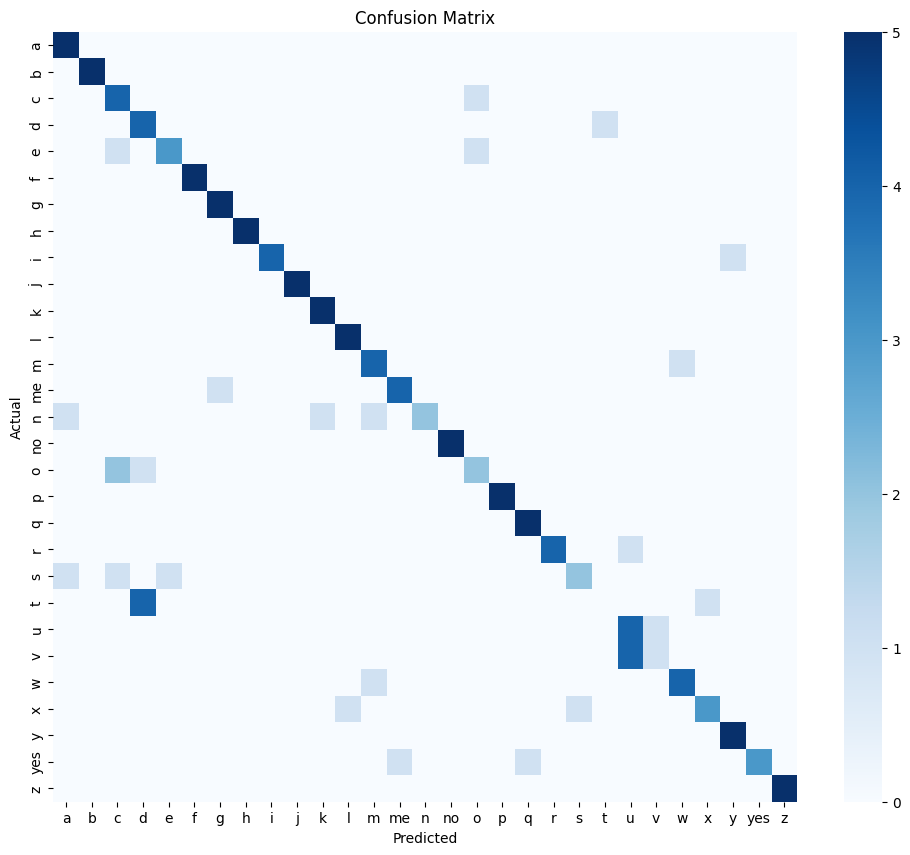

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = label_encoder.classes_

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

           a       0.71      1.00      0.83         5
           b       1.00      1.00      1.00         5
           c       0.50      0.80      0.62         5
           d       0.44      0.80      0.57         5
           e       0.75      0.60      0.67         5
           f       1.00      1.00      1.00         5
           g       0.83      1.00      0.91         5
           h       1.00      1.00      1.00         5
           i       1.00      0.80      0.89         5
           j       1.00      1.00      1.00         5
           k       0.83      1.00      0.91         5
           l       0.83      1.00      0.91         5
           m       0.67      0.80      0.73         5
          me       0.80      0.80      0.80         5
           n       1.00      0.40      0.57         5
          no       1.00      1.00      1.00         5
           o       0.50      0.40      0.44         5
           p       1.00    

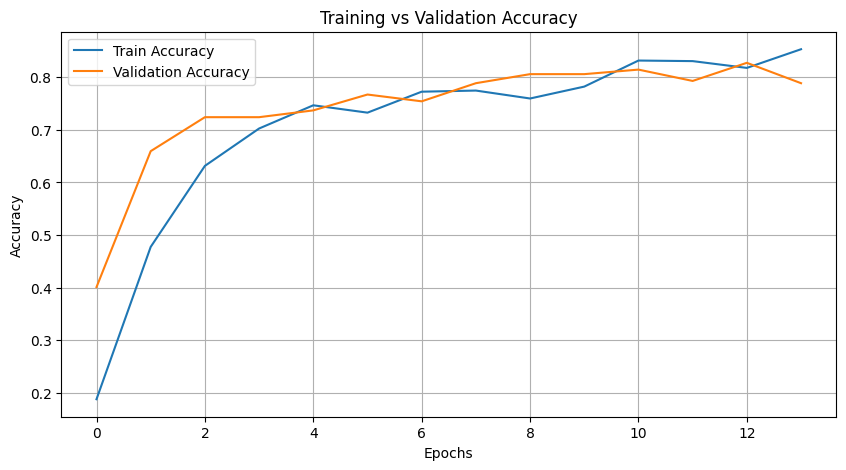

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

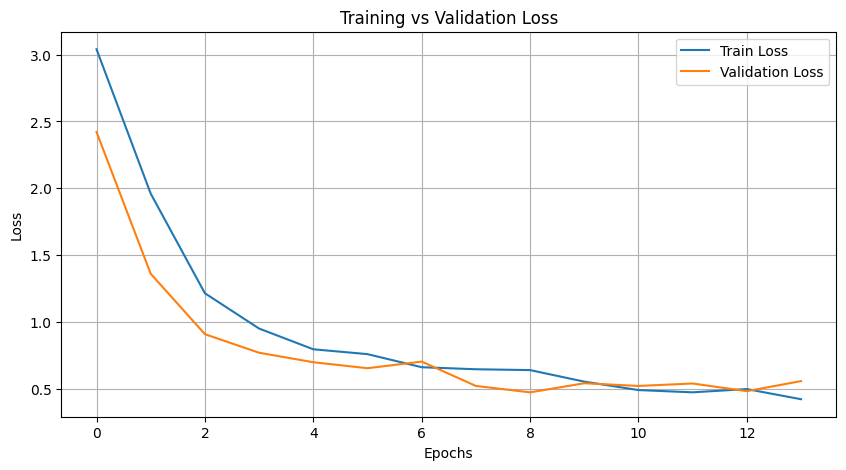

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# Save model
model.save("asl_model.h5")

# Save scaler
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Saved successfully!")

Saved successfully!


In [ ]:
from google.colab import files

files.download("asl_model.h5")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("asl_model.h5")

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("Model loaded!")

Model loaded!


In [ ]:
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("asl_model.h5")

# Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 🔥 FIX (IMPORTANT)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

# Convert
tflite_model = converter.convert()

# Save
with open("asl_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model created successfully!")

Saved artifact at '/tmp/tmp_cjvndlk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 11), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  132623717136912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623717135952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623717128656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623695633232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623695634000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623717129232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623475381392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623475378704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623478537104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623475380816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623475381200

In [ ]:
from google.colab import files
files.download("asl_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(100, 11)),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 100, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,869 (140.11 KB)

 Trainable params: 35,869 (140.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(100, 11)),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 100, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,869 (140.11 KB)

 Trainable params: 35,869 (140.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'me' 'n' 'no' 'o' 'p'
 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'yes' 'z']


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Sample encoded:", y_encoded[:10])

Classes: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'me' 'n' 'no' 'o' 'p'
 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'yes' 'z']
Sample encoded: [ 4 19 27  9 20 21  1  8 15 18]


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, test_idx in gss.split(X, y_encoded, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(100, 11)),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 100, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,869 (140.11 KB)

 Trainable params: 35,869 (140.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.0647 - loss: 3.3453 - val_accuracy: 0.0690 - val_loss: 3.2733
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1638 - loss: 3.1751 - val_accuracy: 0.1724 - val_loss: 3.1784
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2457 - loss: 2.9656 - val_accuracy: 0.2155 - val_loss: 3.0063
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3125 - loss: 2.6667 - val_accuracy: 0.2241 - val_loss: 2.7688
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.2845 - loss: 2.4439 - val_accuracy: 0.2500 - val_loss: 2.6087
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3276 - loss: 2.1503 - val_accuracy: 0.2845 - val_loss: 2.3041
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.3966 - loss: 1.9605 - val_accuracy: 0.2328 - val_loss: 2.2075
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3815 - loss: 1.8415 - val_accuracy: 0.3362 - val_loss:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape (3D → 2D)
X_reshaped = X.reshape(-1, X.shape[2])

# scale
X_scaled = scaler.fit_transform(X_reshaped)

# reshape back (2D → 3D)
X = X_scaled.reshape(X.shape)

# check
print("Mean:", X.mean())
print("Std:", X.std())

Mean: -1.5998743581532061e-15
Std: 1.000000000001261


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, test_idx in gss.split(X, y_encoded, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.2866 - loss: 2.2269 - val_accuracy: 0.4138 - val_loss: 1.7464
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.4784 - loss: 1.6270 - val_accuracy: 0.6466 - val_loss: 1.4923
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5323 - loss: 1.3991 - val_accuracy: 0.6552 - val_loss: 1.2799
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6034 - loss: 1.1964 - val_accuracy: 0.6983 - val_loss: 1.1914
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6358 - loss: 1.1333 - val_accuracy: 0.7069 - val_loss: 1.1396
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6250 - loss: 1.1164 - val_accuracy: 0.6724 - val_loss: 1.0848
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6315 - loss: 1.0740 - val_accuracy: 0.7069 - val_loss: 1.0467
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6659 - loss: 1.0371 - val_accuracy: 0.6983 - val_loss:

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 579ms/step - accuracy: 0.7517 - loss: 0.7338
Test Accuracy: 0.751724123954773


In [ ]:
y_true = y_test

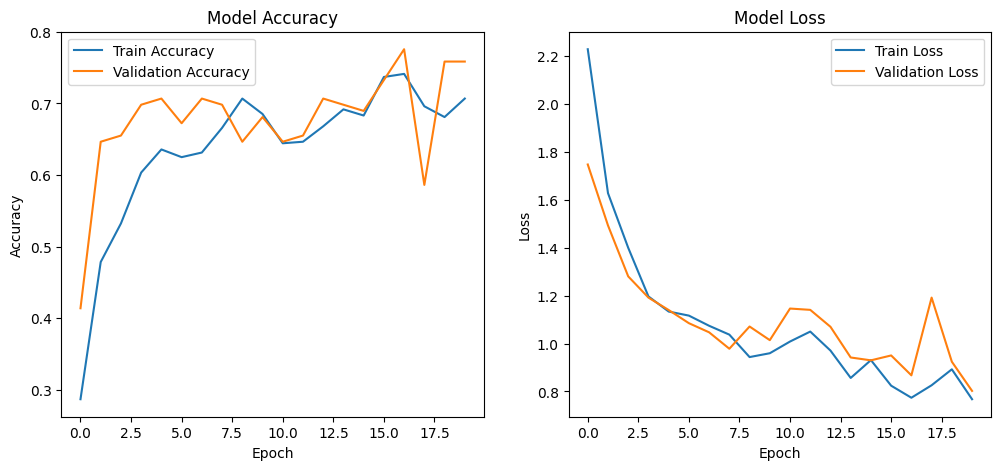

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step


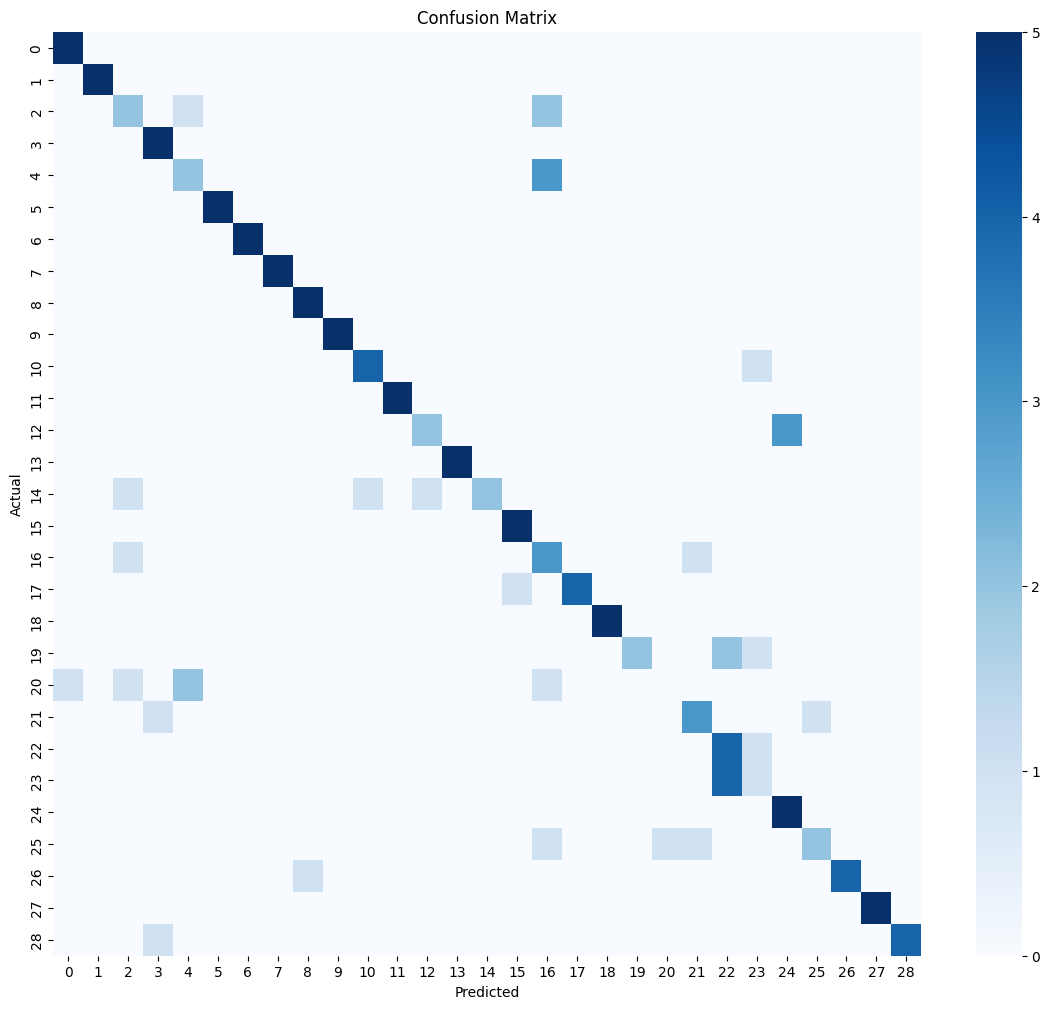

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# TRUE labels (FIXED)
y_true = y_test   # ✅ no argmax

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import numpy as np

# Pick one sample
sample = X_test[0:1]   # shape (1, 100, 11)

# Predict
prediction = model.predict(sample, verbose=0)

# Get class index
pred_class = np.argmax(prediction)

print("Predicted class index:", pred_class)
print("Actual class index:", y_test[0])

Predicted class index: 16
Actual class index: 4


In [ ]:
correct = 0

for i in range(len(X_test)):
    sample = X_test[i:i+1]

    pred = np.argmax(model.predict(sample, verbose=0))

    if pred == y_test[i]:
        correct += 1

print("Accuracy check:", correct / len(X_test))

Accuracy check: 0.7517241379310344


In [ ]:
class_names = ['a','b','c','d','e','f','g','h','i','j','k','l','m','me','n','no','o','p','q','r','s','t','u','v','w','x','y','yes','z']

In [ ]:
class_names = ['a','b','c','d','e','f','g','h','i','j','k','l','m','me','n','no','o','p','q','r','s','t','u','v','w','x','y','yes','z']

for i in range(10):
    sample = X_test[i:i+1]

    pred = np.argmax(model.predict(sample, verbose=0))
    true = y_test[i]

    if pred != true:
        print(f"Wrong at {i}")
        print("Pred:", class_names[pred])
        print("True:", class_names[true])
        print("-"*30)

Wrong at 0
Pred: o
True: e
------------------------------
Wrong at 1
Pred: u
True: r
------------------------------
Wrong at 4
Pred: e
True: s
------------------------------
Wrong at 5
Pred: d
True: t
------------------------------


In [ ]:
# Predict first 10 samples
for i in range(10):
    pred = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    print(pred, y_test[i])

16 4
22 19
27 27
9 9
4 20
3 21
1 1
8 8
15 15
18 18


In [ ]:
class_names = ['a','b','c','d','e','f','g','h','i','j','k','l','m','me','n','no','o','p','q','r','s','t','u','v','w','x','y','yes','z']

for i in range(10):
    pred = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    true = y_test[i]


    print("Pred:", class_names[pred])
    print("True:", class_names[true])

    if pred == true:
        print("✅ Correct")
    else:
        print("❌ Wrong")

    print("-"*30)

NameError: name 'np' is not defined

In [ ]:
model.save("asl_model_75.h5")
print("✅ Model saved")

✅ Model saved


In [ ]:
import numpy as np

np.save("label_classes.npy", label_encoder.classes_)
print("✅ Labels saved")

✅ Labels saved


In [ ]:
import json

with open("training_history.json", "w") as f:
    json.dump(history.history, f)

print("✅ History saved")

✅ History saved


In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# If normal conversion fails, use this:
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("asl_model_75.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved")

Saved artifact at '/tmp/tmpv91opp0z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 11), dtype=tf.float32, name='keras_tensor_177')
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  132623466337424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466339920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466340112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466339344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466340496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466340688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466338960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132623466339536: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite model 

In [ ]:
from google.colab import files

files.download("asl_model_75.h5")
files.download("asl_model_75.tflite")
files.download("label_classes.npy")
files.download("training_history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>